# Facial Emotion Recognition (FER) - CRISP-DM Workflow
### Baseline CNN vs. MobileNetV4 Transfer Learning

This Jupyter Notebook implements a complete machine learning lifecycle for **Facial Emotion Recognition (FER)** based on the **CRISP-DM** (Cross-Industry Standard Process for Data Mining) methodology.

#### Objectives:
1. **Baseline Model**: Design and train a custom Convolutional Neural Network (CNN) from scratch on the FER-2013 dataset.
2. **Main Model**: Perform Transfer Learning using **MobileNetV4** (via PyTorch `timm`), fine-tuning the model for facial emotion classification.
3. **Comparison**: Evaluate and compare both models side-by-side using metrics (Accuracy, F1-Score) and confusion matrices.

#### Methodology (CRISP-DM Phases):
- **Phase 1: Business Understanding**: Understanding the goals and constraints of facial emotion detection.
- **Phase 2: Data Understanding**: Conducting Exploratory Data Analysis (EDA) on the FER-2013 dataset (analyzing class distributions and visualizing faces).
- **Phase 3: Data Preparation**: Constructing data augmentation pipelines and PyTorch `Dataloaders` for both architectures.
- **Phase 4: Modeling**: Building and training both the baseline custom CNN and the MobileNetV4 transfer learning architectures.
- **Phase 5: Evaluation**: Comparing loss/accuracy curves, classification reports, and confusion matrices.
- **Phase 6: Deployment**: Creating a lightweight inference prediction function.


## 1. Environment Setup & Reproducibility Check

To ensure that this notebook executes identically on any system, this section:
- Configures global random seeds (`random`, `numpy`, `torch`).
- Checks for GPU acceleration support (Nvidia **CUDA** or Apple Silicon **MPS**).
- Verifies that all required packages are installed.
- Checks if the **FER-2013** dataset is located in the local directory `./data/fer2013` (or `./data`).


In [ ]:
import sys
import os
import random
import numpy as np

# 1. Set Random Seeds for Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Global random seed set to: {seed}")

# 2. Check Package Availability & GPU/MPS Support
try:
    import torch
    import torchvision
    import timm
    import sklearn
    import pandas
    import matplotlib
    import seaborn
    import tqdm
    print("SUCCESS: All required libraries are installed and ready.")
    print(f"Python Version: {sys.version}")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"Torchvision Version: {torchvision.__version__}")
    print(f"Timm Version: {timm.__version__}")
    
    # Check Device Acceleration
    device = torch.device("cpu")
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    print(f"Target computation device: {device}")
    
    set_seed(42)
except ImportError as e:
    print(f"ERROR: {e}")
    print("Please install the missing packages by running: pip install -r requirements.txt")
    device = torch.device("cpu")

# 3. Verify Dataset Directory
data_dir = "./data/fer2013"
if not os.path.exists(data_dir) and os.path.exists("./data/train"):
    data_dir = "./data"
elif not os.path.exists(data_dir) and os.path.exists("./data/archive/train"):
    data_dir = "./data/archive"

print(f"Dataset root path: {data_dir}")
if os.path.exists(data_dir):
    print("SUCCESS: Dataset directory found. Contents:", os.listdir(data_dir))
else:
    print("WARNING: FER-2013 dataset not found in './data/fer2013' or './data'!")
    print("To run the training cells, please:")
    print("  1. Download the dataset from: https://www.kaggle.com/datasets/msambare/fer2013")
    print("  2. Create a folder named 'data' and extract the ZIP file inside it.")


## Phase 1: Business Understanding

Facial Expression Recognition (FER) is a crucial computer vision challenge with applications in:
- **Human-Computer Interaction (HCI)**: Adapting user interfaces based on user mood.
- **Mental Health & Healthcare**: Monitoring patient mood transitions.
- **Market Research**: Analyzing customer responses to advertisements.
- **Automotive Safety**: Detecting driver fatigue or frustration.

### Key Constraints:
1. **Low Resolution**: FER-2013 images are grayscale and only 48x48 pixels, making structural facial details hard to capture.
2. **Label Noise**: Images are captured 'in-the-wild' and annotations occasionally contain subjective ambiguity.
3. **Class Imbalance**: Certain classes (such as `disgust`) contain extremely few samples compared to `happy` or `neutral`, which biased model predictions. This requires specialized evaluation metrics (F1-Score, Confusion Matrices) rather than relying solely on accuracy.


## Phase 2: Data Understanding (EDA)

In this section, we analyze our data distributions and visualize the images to build intuition. Specifically:
1. **Quantitative Check**: Compute total image counts across train and test sets.
2. **Distribution Plot**: Use Seaborn bar plots to identify class imbalance.
3. **Visual Examination**: Display random sample faces per category to understand brightness variance, alignment, and facial structures.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.exists(data_dir):
    train_dir = os.path.join(data_dir, "train")
    test_dir = os.path.join(data_dir, "test")
    
    def count_classes(dir_path):
        data = []
        for class_name in sorted(os.listdir(dir_path)):
            class_path = os.path.join(dir_path, class_name)
            if os.path.isdir(class_path):
                num_images = len(os.listdir(class_path))
                data.append({"Emotion": class_name, "Count": num_images})
        return pd.DataFrame(data)
        
    train_counts = count_classes(train_dir)
    test_counts = count_classes(test_dir)
    
    print("--- Train Set Class Distribution ---")
    print(train_counts)
    print("\n--- Test Set Class Distribution ---")
    print(test_counts)
    
    # Visualize Class Distribution
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    sns.barplot(data=train_counts, x="Emotion", y="Count", palette="viridis")
    plt.title("Train Set: Class Distribution")
    plt.xticks(rotation=45)
    plt.ylabel("Number of Images")
    
    plt.subplot(1, 2, 2)
    sns.barplot(data=test_counts, x="Emotion", y="Count", palette="magma")
    plt.title("Test Set: Class Distribution")
    plt.xticks(rotation=45)
    plt.ylabel("Number of Images")
    
    plt.tight_layout()
    plt.show()
else:
    print("EDA skipped: Dataset directory not found. Please set up the dataset directories first.")


In [ ]:
from PIL import Image

if os.path.exists(data_dir):
    train_dir = os.path.join(data_dir, "train")
    emotions = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    
    # Display 5 sample faces per class
    fig, axes = plt.subplots(len(emotions), 5, figsize=(15, 2.5 * len(emotions)))
    
    for idx, emotion in enumerate(emotions):
        emotion_dir = os.path.join(train_dir, emotion)
        images = [f for f in os.listdir(emotion_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        selected_images = random.sample(images, min(5, len(images)))
        
        for col_idx, img_name in enumerate(selected_images):
            img_path = os.path.join(emotion_dir, img_name)
            img = Image.open(img_path)
            img_np = np.array(img)
            
            ax = axes[idx, col_idx]
            ax.imshow(img, cmap="gray")
            ax.set_title(f"{emotion} ({img.size[0]}x{img.size[1]})", fontsize=9)
            ax.axis("off")
            
            if col_idx == 0:
                print(f"Emotion: {emotion:<10} | Range: [{img_np.min():>3}, {img_np.max():>3}] | Mean pixel: {img_np.mean():.1f}")
                
    plt.suptitle("Sample Faces per Emotion Class (FER-2013)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("EDA skipped: Dataset directory not found.")


## Phase 3: Data Preparation

In this phase, we build our image transformation pipelines and wrap them using PyTorch's `Dataset` and `DataLoader` classes.

### Key Pipelines:
1. **Baseline Pipeline**: Keeps the native **48x48** size. We apply light data augmentations (`RandomHorizontalFlip`, `RandomRotation(15)`) to reduce overfitting and normalize with standard single-channel equivalence.
2. **MobileNetV4 Pipeline**: Resizes images to **224x224** (the resolution standard for pre-trained weights). We apply similar augmentations and normalize using the standard **ImageNet** mean and standard deviation: `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`.

*Note: The PyTorch `ImageFolder` class automatically replicates grayscale single-channel values to 3-channel (RGB) format upon loading, allowing us to feed them straight into the models.*


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

BATCH_SIZE = 64
IMG_SIZE_BASELINE = 48
IMG_SIZE_MOBILENET = 224

# Define Baseline transformations
baseline_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_BASELINE, IMG_SIZE_BASELINE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

baseline_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_BASELINE, IMG_SIZE_BASELINE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Define MobileNetV4 transformations
mobilenet_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_MOBILENET, IMG_SIZE_MOBILENET)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mobilenet_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_MOBILENET, IMG_SIZE_MOBILENET)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instantiate Datasets and Dataloaders
if os.path.exists(data_dir):
    train_dir = os.path.join(data_dir, "train")
    test_dir = os.path.join(data_dir, "test")
    
    # Baseline datasets
    baseline_train_dataset = datasets.ImageFolder(root=train_dir, transform=baseline_train_transform)
    baseline_test_dataset = datasets.ImageFolder(root=test_dir, transform=baseline_test_transform)
    
    # MobileNetV4 datasets
    mobilenet_train_dataset = datasets.ImageFolder(root=train_dir, transform=mobilenet_train_transform)
    mobilenet_test_dataset = datasets.ImageFolder(root=test_dir, transform=mobilenet_test_transform)
    
    # Dataloaders
    baseline_train_loader = DataLoader(baseline_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    baseline_test_loader = DataLoader(baseline_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    
    mobilenet_train_loader = DataLoader(mobilenet_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    mobilenet_test_loader = DataLoader(mobilenet_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    
    classes = baseline_train_dataset.classes
    print(f"SUCCESS: Datasets configured.")
    print(f"Target Emotion Classes: {classes}")
    print(f"Baseline Set: {len(baseline_train_dataset)} Train, {len(baseline_test_dataset)} Test Samples")
    print(f"MobileNet Set: {len(mobilenet_train_dataset)} Train, {len(mobilenet_test_dataset)} Test Samples")
else:
    print("DataLoader configuration skipped: Dataset directory not found.")


## Phase 4: Modeling

This section sets up our model architectures, optimization schemes, and training loops.

### 1. Model 1: Custom Baseline CNN
Our baseline model is designed from scratch. It is a standard VGG-like feedforward CNN with four convolution blocks:
- **Blocks**: `Conv2d` -> `BatchNorm2d` -> `ReLU` -> `MaxPool2d` -> `Dropout`.
- **Dense Layer**: Flat tensor is fed to a fully connected linear layer of size `512` with batch normalization and dropout, then mapped to `7` outputs.
- **Objective**: Provide a baseline accuracy and speed baseline to compare with Transfer Learning.

### 2. Model 2: MobileNetV4 Transfer Learning
We load `mobilenetv4_conv_small` via PyTorch `timm` with pre-trained ImageNet weights.
- **Head Replacement**: We replace the original ImageNet projection classifier layer with a new linear head mapping to our 7 classes.
- **Two-Phase Transfer Learning Strategy**:
  1. **Feature Extraction**: Freeze all backbone layers, training only our newly initialized classification head for a few epochs (learning rate = `1e-3`).
  2. **Fine-Tuning**: Unfreeze the entire network and train with a very low learning rate (learning rate = `1e-5`) to align the backbone features to facial expressions without destroying ImageNet representations.


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()
        # Input: 3 channels of 48x48
        # Block 1: Output 32 channels. Size: 48 -> pool -> 24
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Block 2: Output 64 channels. Size: 24 -> pool -> 12
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3: Output 128 channels. Size: 12 -> pool -> 6
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Block 4: Output 256 channels. Size: 6 -> pool -> 3
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        # Classification Head: 256 * 3 * 3 = 2304 features
        self.fc1 = nn.Linear(256 * 3 * 3, 512)
        self.fc_bn = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.dropout(x)
        
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc_bn(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Verify Baseline setup
try:
    baseline_model = BaselineCNN(num_classes=7).to(device)
    print("SUCCESS: Baseline CNN Model constructed and loaded to device.")
    total_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")
except Exception as e:
    print(f"ERROR: {e}")


SUCCESS: Baseline CNN Model constructed and loaded to device.
Total trainable parameters: 1,574,151


In [11]:
try:
    # Get MobileNetV4 model architecture from timm
    # 'mobilenetv4_conv_small' is chosen as a modern lightweight feature extraction backbone
    mobilenet_model = timm.create_model('mobilenetv4_conv_small', pretrained=True)
    
    # Replace Classifier Head with 7 output units for FER classification
    mobilenet_model.reset_classifier(num_classes=7)
    mobilenet_model = mobilenet_model.to(device)
    
    print("SUCCESS: MobileNetV4 Model constructed and loaded to device.")
    total_params_mn = sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params_mn:,}")
except Exception as e:
    print(f"ERROR: {e}")


SUCCESS: MobileNetV4 Model constructed and loaded to device.
Total trainable parameters: 2,501,991


In [12]:
import time
from tqdm.auto import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Progress bar setup
    pbar = tqdm(dataloader, desc="  Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{100 * correct / total:.2f}%"})
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="  Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def run_training(model, train_loader, test_loader, epochs, lr, device, save_path, weight_decay=1e-2):
    criterion = nn.CrossEntropyLoss()
    # Use AdamW optimizer with default weight decay
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = 0.0
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, test_loader, criterion, device)
        scheduler.step()
        
        epoch_time = time.time() - start_time
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch [{epoch:02d}/{epochs:02d}] ({epoch_time:.1f}s) | "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")
              
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"  --> Saved new best model checkpoint to '{save_path}' (Val Acc: {best_acc*100:.2f}%)")
            
    return history


### Training the Baseline CNN

We train our baseline network from scratch for 10 epochs. We use a learning rate of `1e-3` with Cosine Annealing.


In [13]:
EPOCHS_BASELINE = 10
LR_BASELINE = 1e-3
SAVE_PATH_BASELINE = "best_baseline_cnn.pth"

if os.path.exists(data_dir):
    print("Starting training loop for Baseline CNN...")
    baseline_history = run_training(
        model=baseline_model,
        train_loader=baseline_train_loader,
        test_loader=baseline_test_loader,
        epochs=EPOCHS_BASELINE,
        lr=LR_BASELINE,
        device=device,
        save_path=SAVE_PATH_BASELINE
    )
else:
    print("Training skipped: Dataset not found.")


Starting training loop for Baseline CNN...


  Training:   0%|          | 0/449 [00:00<?, ?it/s]Python(18955) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18989) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19007) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19030) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  Validating:   0%|          | 0/113 [00:00<?, ?it/s]                                 Python(19258) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19287) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19303) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19316) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch [01/10] (53.7s) | Train Loss: 1.6619 - Train Acc: 34.62% | Val Loss: 1.5281 - Val Acc: 41.86%
  --> Saved new best model checkpoint to 'best_baseline_cnn.pth' (Val Acc: 41.86%)


  Training:   0%|          | 0/449 [00:00<?, ?it/s]Python(19486) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19519) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19523) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19539) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  Validating:   0%|          | 0/113 [00:00<?, ?it/s]                                 Python(19777) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19790) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19806) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19810) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch [02/10] (57.7s) | Train Loss: 1.4533 - Train Acc: 43.72% | Val Loss: 1.2929 - Val Acc: 49.93%
  --> Saved new best model checkpoint to 'best_baseline_cnn.pth' (Val Acc: 49.93%)


...

Epoch [08/10] (54.5s) | Train Loss: 1.1938 - Train Acc: 54.52% | Val Loss: 1.0972 - Val Acc: 57.41%


  Training:   0%|          | 0/449 [00:00<?, ?it/s]Python(22430) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22445) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22458) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22462) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  Validating:   0%|          | 0/113 [00:00<?, ?it/s]                                 Python(22639) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22656) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22668) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22671) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch [09/10] (51.4s) | Train Loss: 1.1853 - Train Acc: 54.94% | Val Loss: 1.0930 - Val Acc: 58.23%
  --> Saved new best model checkpoint to 'best_baseline_cnn.pth' (Val Acc: 58.23%)


  Training:   0%|          | 0/449 [00:00<?, ?it/s]Python(22790) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22792) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22807) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22811) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  Validating:   0%|          | 0/113 [00:00<?, ?it/s]                                 Python(23006) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23020) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23032) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23039) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch [10/10] (51.1s) | Train Loss: 1.1775 - Train Acc: 55.22% | Val Loss: 1.0887 - Val Acc: 58.33%
  --> Saved new best model checkpoint to 'best_baseline_cnn.pth' (Val Acc: 58.33%)


### Training the MobileNetV4 Model (Transfer Learning)

We use our two-phase training process:
- **Phase 1: Feature Extraction** (5 epochs): Backbones frozen, learning rate = `1e-3`.
- **Phase 2: Fine-Tuning** (5 epochs): Backbone unfrozen, learning rate = `1e-5`.


In [14]:
EPOCHS_FE = 5
EPOCHS_FT = 5
SAVE_PATH_MOBILENET = "best_mobilenet_v4.pth"

if os.path.exists(data_dir):
    # --- PHASE 1: Feature Extraction ---
    print("=== Phase 1: Feature Extraction (Backbone Frozen) ===")
    # Freeze all parameters
    for param in mobilenet_model.parameters():
        param.requires_grad = False
    # Unfreeze only the classifier head
    for param in mobilenet_model.classifier.parameters():
        param.requires_grad = True
        
    history_fe = run_training(
        model=mobilenet_model,
        train_loader=mobilenet_train_loader,
        test_loader=mobilenet_test_loader,
        epochs=EPOCHS_FE,
        lr=1e-3,
        device=device,
        save_path=SAVE_PATH_MOBILENET
    )
    
    # --- PHASE 2: Fine-Tuning ---
    print("\n=== Phase 2: Fine-Tuning (All Layers Unfrozen) ===")
    # Unfreeze everything
    for param in mobilenet_model.parameters():
        param.requires_grad = True
        
    history_ft = run_training(
        model=mobilenet_model,
        train_loader=mobilenet_train_loader,
        test_loader=mobilenet_test_loader,
        epochs=EPOCHS_FT,
        lr=1e-5,  # Very low learning rate to prevent catastrophic forgetting
        device=device,
        save_path=SAVE_PATH_MOBILENET
    )
    
    # Combine both histories into one for analysis
    mobilenet_history = {
        "train_loss": history_fe["train_loss"] + history_ft["train_loss"],
        "train_acc": history_fe["train_acc"] + history_ft["train_acc"],
        "val_loss": history_fe["val_loss"] + history_ft["val_loss"],
        "val_acc": history_fe["val_acc"] + history_ft["val_acc"]
    }
else:
    print("Training skipped: Dataset not found.")


=== Phase 1: Feature Extraction (Backbone Frozen) ===


  Training:   0%|          | 0/449 [00:00<?, ?it/s]Python(23319) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23338) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23353) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23360) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  Validating:   0%|          | 0/113 [00:00<?, ?it/s]                                 Python(23821) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23840) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23992) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(24067) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch [01/05] (203.5s) | Train Loss: 1.6555 - Train Acc: 34.40% | Val Loss: 1.6171 - Val Acc: 36.70%
  --> Saved new best model checkpoint to 'best_mobilenet_v4.pth' (Val Acc: 36.70%)


  Training:   0%|          | 0/449 [00:00<?, ?it/s]Python(24559) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(24638) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(24663) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(24693) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  Validating:   0%|          | 0/113 [00:00<?, ?it/s]                                 Python(26970) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27044) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27098) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27151) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch [02/05] (465.6s) | Train Loss: 1.5885 - Train Acc: 37.94% | Val Loss: 1.5939 - Val Acc: 38.06%
  --> Saved new best model checkpoint to 'best_mobilenet_v4.pth' (Val Acc: 38.06%)


...

Epoch [03/05] (211.2s) | Train Loss: 1.3062 - Train Acc: 50.12% | Val Loss: 1.3306 - Val Acc: 48.93%
  --> Saved new best model checkpoint to 'best_mobilenet_v4.pth' (Val Acc: 48.93%)


  Training:   0%|          | 0/449 [00:00<?, ?it/s]Python(33522) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(33551) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(33563) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(33582) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  Validating:   0%|          | 0/113 [00:00<?, ?it/s]                                 Python(34737) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34740) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34755) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34758) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch [04/05] (209.0s) | Train Loss: 1.2637 - Train Acc: 52.24% | Val Loss: 1.3019 - Val Acc: 49.79%
  --> Saved new best model checkpoint to 'best_mobilenet_v4.pth' (Val Acc: 49.79%)


  Training:   0%|          | 0/449 [00:00<?, ?it/s]Python(34914) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34938) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34963) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(34967) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  Validating:   0%|          | 0/113 [00:00<?, ?it/s]                                 Python(35951) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(35968) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(35975) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(35989) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch [05/05] (182.8s) | Train Loss: 1.2446 - Train Acc: 52.92% | Val Loss: 1.2858 - Val Acc: 50.98%
  --> Saved new best model checkpoint to 'best_mobilenet_v4.pth' (Val Acc: 50.98%)


## Phase 5: Evaluation & Comparison

To rigorously evaluate both models, this section contains:
1. **Learning Curves Plot**: Compares Train vs. Val loss and accuracy across epochs.
2. **Detailed Class Metrics**: Generates classification reports (Precision, Recall, F1-Score) for each emotion category.
3. **Confusion Matrices**: Generates heatmaps visualizing misclassification details (e.g., confusing `fear` with `sad`, or `sad` with `neutral`).


--- Baseline CNN Curves ---


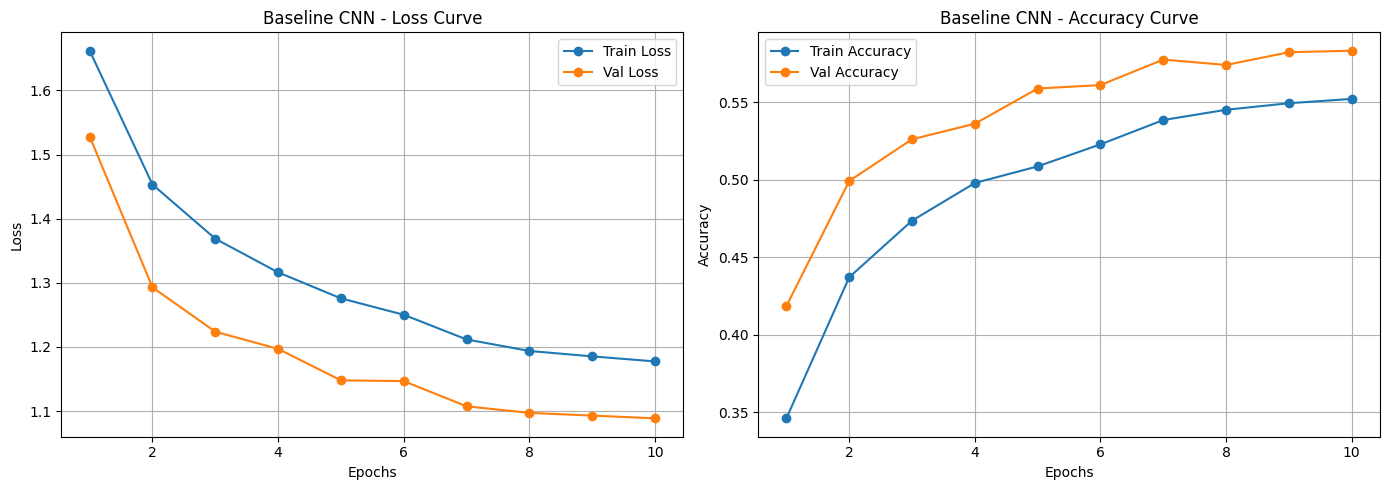

--- MobileNetV4 Transfer Learning Curves ---


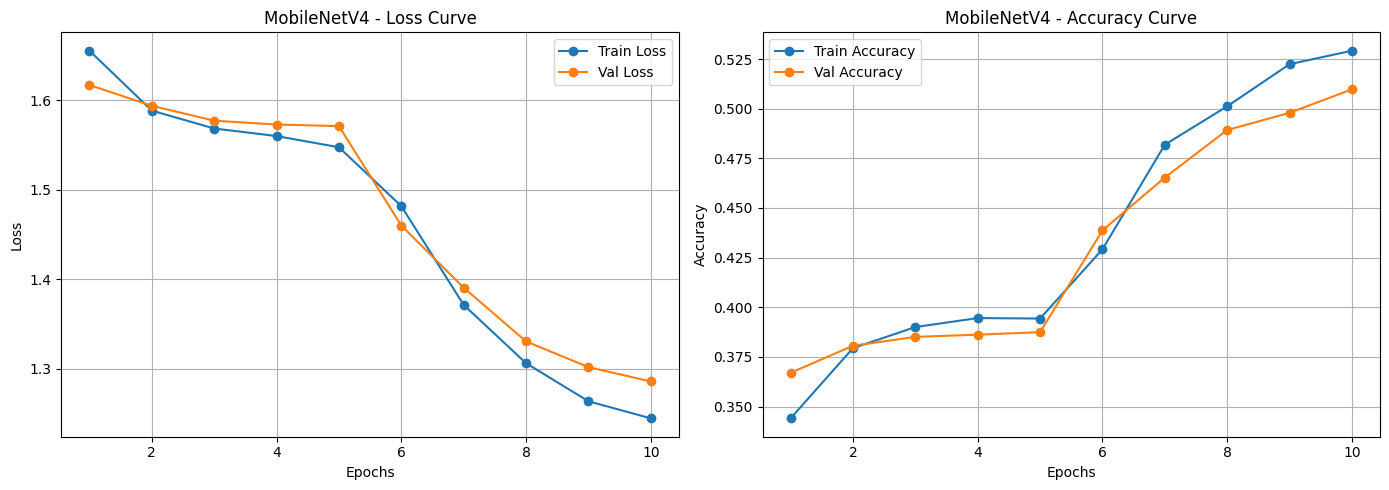

In [15]:
def plot_learning_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], 'o-', label='Train Loss')
    plt.plot(epochs, history["val_loss"], 'o-', label='Val Loss')
    plt.title(f"{title} - Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    
    # Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], 'o-', label='Train Accuracy')
    plt.plot(epochs, history["val_acc"], 'o-', label='Val Accuracy')
    plt.title(f"{title} - Accuracy Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

if os.path.exists(data_dir):
    print("--- Baseline CNN Curves ---")
    plot_learning_curves(baseline_history, "Baseline CNN")
    print("--- MobileNetV4 Transfer Learning Curves ---")
    plot_learning_curves(mobilenet_history, "MobileNetV4")
else:
    print("Plotting curves skipped: Dataset not found.")


Loaded best model weights for Baseline CNN from 'best_baseline_cnn.pth'


Evaluating Baseline CNN:   0%|          | 0/113 [00:00<?, ?it/s]Python(36467) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(36481) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(36485) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(36499) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Evaluating Baseline CNN: 100%|██████████| 113/113 [00:16<00:00,  6.69it/s]



==================== Baseline CNN Evaluation Report ====================
              precision    recall  f1-score   support

       angry       0.56      0.40      0.46       958
     disgust       0.63      0.20      0.30       111
        fear       0.49      0.18      0.26      1024
       happy       0.76      0.85      0.80      1774
     neutral       0.50      0.62      0.55      1233
         sad       0.42      0.58      0.49      1247
    surprise       0.69      0.73      0.71       831

    accuracy                           0.58      7178
   macro avg       0.58      0.51      0.51      7178
weighted avg       0.58      0.58      0.56      7178



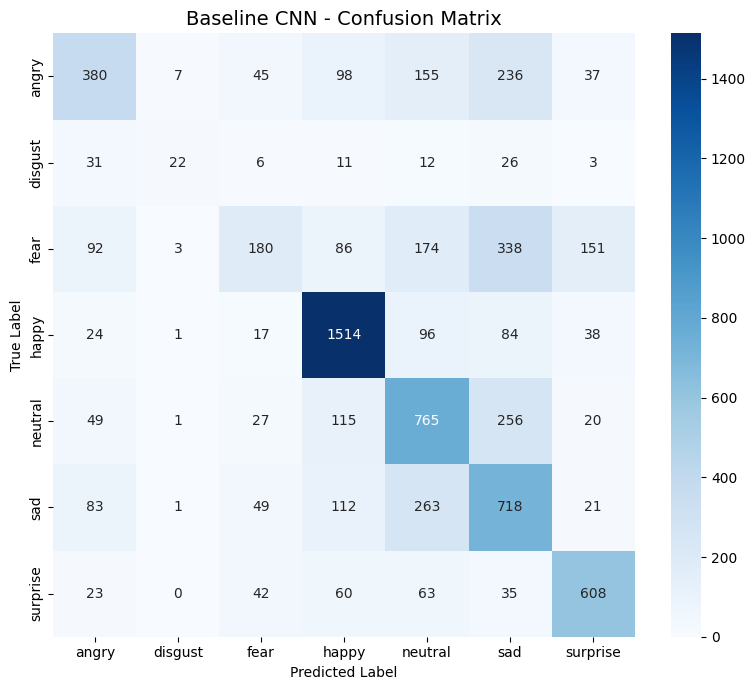

Loaded best model weights for MobileNetV4 Transfer Learning from 'best_mobilenet_v4.pth'


Evaluating MobileNetV4 Transfer Learning:   0%|          | 0/113 [00:00<?, ?it/s]/Users/franco/Documents/source/Proyectos Web/machine_learning/env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Python(36620) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(36635) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(36638) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(36652) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Evaluating MobileNetV4 Transfer Learning: 100%|██████████| 113/113 [00:23<00:00,  4.73it/s]



==================== MobileNetV4 Transfer Learning Evaluation Report ====================
              precision    recall  f1-score   support

       angry       0.39      0.38      0.39       958
     disgust       0.33      0.02      0.03       111
        fear       0.34      0.21      0.26      1024
       happy       0.67      0.80      0.72      1774
     neutral       0.44      0.50      0.47      1233
         sad       0.40      0.41      0.41      1247
    surprise       0.64      0.65      0.64       831

    accuracy                           0.51      7178
   macro avg       0.46      0.42      0.42      7178
weighted avg       0.49      0.51      0.49      7178



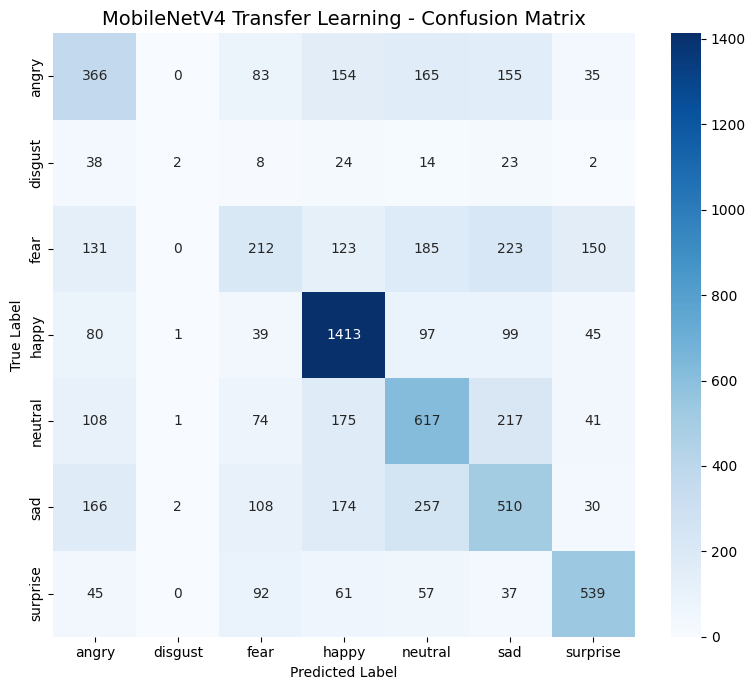

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, dataloader, weight_path, classes, title, device):
    # Load best checkpoint weights
    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print(f"Loaded best model weights for {title} from '{weight_path}'")
        
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Evaluating {title}"):
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())
            
    # Print Classification Report
    print(f"\n==================== {title} Evaluation Report ====================")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f"{title} - Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

if os.path.exists(data_dir):
    evaluate_model(
        model=baseline_model,
        dataloader=baseline_test_loader,
        weight_path=SAVE_PATH_BASELINE,
        classes=classes,
        title="Baseline CNN",
        device=device
    )
    evaluate_model(
        model=mobilenet_model,
        dataloader=mobilenet_test_loader,
        weight_path=SAVE_PATH_MOBILENET,
        classes=classes,
        title="MobileNetV4 Transfer Learning",
        device=device
    )
else:
    print("Evaluation skipped: Dataset not found.")


## Phase 6: Deployment & Inference Testing

To operationalize our facial emotion recognition model, we define a helper function `predict_facial_emotion` that:
1. Loads any RGB/grayscale image.
2. Applies the necessary preprocessing transformations (resize, normalization).
3. Feeds the tensor to the fine-tuned MobileNetV4 model.
4. Displays the image along with the predicted class and softmax probabilities for all emotions.


In [17]:
def predict_facial_emotion(image_path, model, transform, classes, device, weight_path=None):
    if not os.path.exists(image_path):
        print(f"ERROR: Image file not found at: {image_path}")
        return
        
    # Load weights if path is provided
    if weight_path and os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=device))
        
    # Load image and convert to RGB
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)  # Add batch dimension
    
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]
        confidence, pred_idx = torch.max(probabilities, 0)
        
    pred_class = classes[pred_idx.item()]
    
    # Visualization
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class} ({confidence.item()*100:.2f}%)", fontsize=14)
    plt.axis("off")
    plt.show()
    
    print("Softmax Probabilities:")
    for cls_name, prob in zip(classes, probabilities.cpu().numpy()):
        print(f"  {cls_name:<10}: {prob*100:6.2f}%")

# Inference sanity check example using a random test set image (commented out by default)
# if os.path.exists(data_dir):
#     test_dir = os.path.join(data_dir, "test")
#     random_class = random.choice(os.listdir(test_dir))
#     class_dir = os.path.join(test_dir, random_class)
#     if os.path.isdir(class_dir):
#         random_file = random.choice([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
#         sample_image_path = os.path.join(class_dir, random_file)
#         print(f"Running inference test on sample: {sample_image_path}")
#         predict_facial_emotion(
#             image_path=sample_image_path,
#             model=mobilenet_model,
#             transform=mobilenet_test_transform,
#             classes=classes,
#             device=device,
#             weight_path=SAVE_PATH_MOBILENET
#         )
